### Problem 3

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

a) Load data and remove games with missing values

In [12]:
df = pd.read_csv('data/nba_games.csv')
df = df.dropna()
df.shape

(26552, 21)

b) Construct target vector y and feature matrix X

In [ ]:
# Get unique teams
teams = df['HOME_TEAM_ID'].unique()
print(len(teams))

# convert id to index
team_idx = {team: idx for idx, team in enumerate(sorted(teams))}

y = (df['PTS_home'] - df['PTS_away']).values  

X = np.zeros((len(df), 30 + 1))  # +1 for bias term
for i, (_, row) in enumerate(df.iterrows()):
    h_idx = team_idx[row['HOME_TEAM_ID']]
    a_idx = team_idx[row['VISITOR_TEAM_ID']]
    X[i, h_idx] = 1 # home
    X[i, a_idx] = -1 # away
    X[i, -1] = 1  # bias

30


X 26552 rows for 26552 games, and 31 columns for 30 teams and a bias term. For each game (row) the column corresponding to the home team is set to +1, and the column corresponding to the away team is set to -1. All other columns are set to 0. The last column represents the bias and is set to 1.
X is constructed this way so that it "selects" the home and away teams while multiplying Xθ, and calculates the difference in skill between home and away teams, + bias.

c) Split into training and test sets 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

d) Rank of matrix X

In [15]:
np.linalg.matrix_rank(X)

np.int64(30)

Rank(X) = 30 < min(26552, 31), so X is not full rank. This means that $X^TX$ is not invertible so the least square solution $$\hat{\theta} = (X^TX)^{-1}X^Ty$$ to the equation $y=Xθ$ is not unique.
There are infinitely many θ that satisfy the least square solution. This shows that the model finds relative skill differences between teams, not absolute skill levels (impossible).

e) Least-squares solution

In [16]:
theta_hat = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train # using pseudo-inverse
print("estimated skill levels (theta):", theta_hat[:-1])  # exclude bias
print("estimated bias:", theta_hat[-1])

estimated skill levels (theta): [-1.70230216  2.08071757 -0.5430114  -1.24827832 -0.47660866  2.32850132
  1.82761832  2.67983669  2.16859834  0.60425239  0.16533423  1.60325246
 -0.13315511 -1.67392278 -2.20277397 -2.65555846 -1.60428558  0.28005754
 -1.2970057   0.87714584 -0.37599045 -2.37974977  4.43636744  0.7159761
  0.63918756  1.78085403  0.01553862 -2.07965645 -0.59857692 -3.23236271]
estimated bias: 2.830443731129141


f) Role of bias term

The bias term shifts the prediction by a constant. In this case a positive bias represents home court advantage, as seen in the equation $$y_H-y_A={\theta}_H-{\theta}_A+b$$ where the bias is added to the skill difference between the home and away teams to get the point difference.

g) RMSE, R^2

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

# perform predictions
y_train_pred = X_train @ theta_hat
y_test_pred  = X_test  @ theta_hat

# RMSE and R^2
print("RMSE (train):", rmse(y_train, y_train_pred))
print("RMSE (test):", rmse(y_test, y_test_pred))
print("R^2 (train):", r2(y_train, y_train_pred))
print("R^2 (test):", r2(y_test, y_test_pred))

RMSE (train): 13.329370523323199
RMSE (test): 13.130035908693728
R^2 (train): 0.034271229098378875
R^2 (test): 0.030624182428912183


- The R^2 value of 0.03 is low, and shows that only 3% of the variance in point differentials is explained by the model. 
- RMSE = 13 means that on average the model predictions are off by 13 points. This is a large error.
- The RMSE and R^2 for both the training and test sets are nearly identical, showing that the model is not overfitted.
- The poor R^2 and RMSE values show that the model is not a good predictor for point differentials in a game.
- The model parameters alone are not enough for making good predictions for point differentials in a game, as there are other sources of error and noise inherant in basketball games

h) New feature: win scores

In [ ]:
team_win_scores = {}
for team_id in sorted(teams):
    # Home wins
    home_games = df[df['HOME_TEAM_ID'] == team_id]
    wins = home_games['HOME_TEAM_WINS'].sum()
    
    # Away wins 
    away_games = df[df['VISITOR_TEAM_ID'] == team_id]
    wins += (1 - away_games['HOME_TEAM_WINS']).sum()
    
    # ties do not occur in NBA games, so they do not need to be accounted for

    team_win_scores[team_id] = wins * 3 # 3 points per win
    
win_scores_df = pd.DataFrame({
    'Team ID': list(team_win_scores.keys()),
    'Win Score': list(team_win_scores.values())
}).sort_values('Win Score', ascending=False).reset_index(drop=True)

display(win_scores_df)

,Team ID,Win Score
0,1610612759,3549
1,1610612748,3219
2,1610612738,3165
3,1610612742,3111
4,1610612744,3060
5,1610612745,2988
6,1610612743,2982
7,1610612762,2856
8,1610612747,2841
9,1610612760,2784


i) Plot win scores vs estimated team skill levels (theta)

/tmp/ipykernel_109502/155935288.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


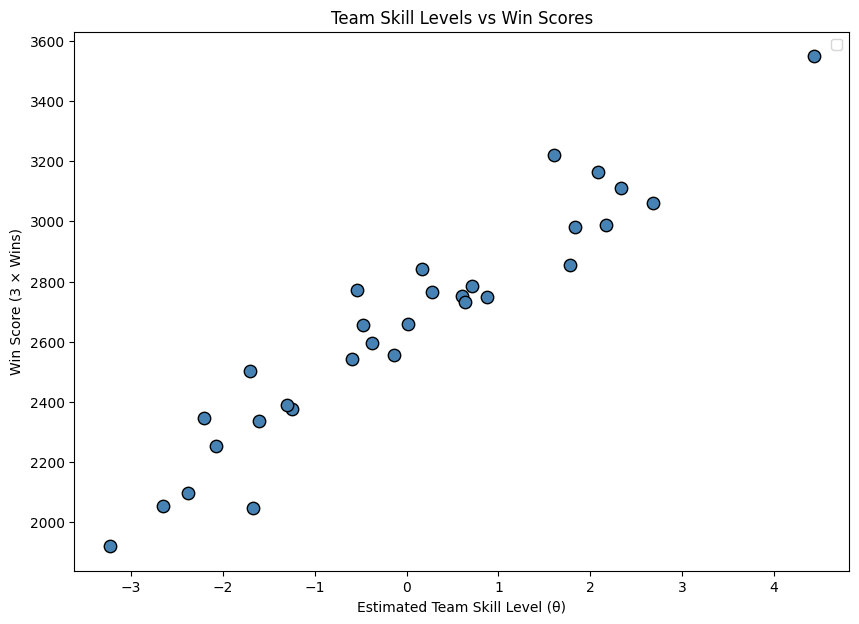

Pearson correlation: 0.9553


In [29]:
win_scores_arr = np.array([team_win_scores[t] for t in sorted(teams)])
team_skills = theta_hat[:-1]  # exclude bias

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(team_skills, win_scores_arr, color='steelblue', edgecolors='black', s=80)

ax.set_xlabel('Estimated Team Skill Level (θ)')
ax.set_ylabel('Win Score (3 × Wins)')
ax.set_title('Team Skill Levels vs Win Scores')
ax.legend()
plt.show()

corr = np.corrcoef(team_skills, win_scores_arr)[0, 1]
print(f"Pearson correlation: {corr:.4f}")  # 0.955


The scatter plot shows a clear linear trend between win scores and team skill levels. The Pearson correlation between the two variables is r=0.955 which is close to 1, showing a strong positive linear relationship between the two variables.\
This shows that the estimated skill levels is a strong predictor of number of wins of a team.\
Although the model is not a good predictor for individual games, it is a strong predictor for the overall performance of the team. This shows that individual games have high variability and cannot be predicted with high confidence based on team skill level.